# 02 · EDA — Titanic

**Dataset:** `data/titanic_clean.csv` (the original Kaggle file — light cleaning still needed).
**Covers:** univariate EDA · bivariate EDA · correlation · reading a distribution.
**Time yourself:** ~30 minutes.

Most of these have a **number** as the answer and a **sentence** as the real answer.
Say the sentence out loud.

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('data/titanic_clean.csv')
df.columns = df.columns.str.lower()
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda s: s.fillna(s.median()))
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

## Part A — Univariate

### Q1. What is the overall survival rate? Is the target balanced?

<details><summary>hint</summary>

`value_counts(normalize=True)` gives proportions. The mean of a 0/1 column is also the rate.

</details>

In [79]:
# your code here
df["survived"].mean()

# ~38% survived / 62% died. Mildly imbalanced -- not enough to need SMOTE, but enough
# that a "always predict died" model scores 62% accuracy. That's the number to beat.

np.float64(0.3838383838383838)

In [80]:
df["survived"].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Q2. Plot `age` and `fare`: histogram + boxplot side by side for each. Print the skew of
both. Which one is heavily skewed, and what would you do about it?

<details><summary>hint</summary>

`plt.subplots(2, 2)` then index `axes[row, col]`. Skew above ~1 in absolute value is the usual 'this is skewed' threshold.

</details>

age     0.53
fare    4.79
dtype: float64


<Axes: xlabel='fare'>

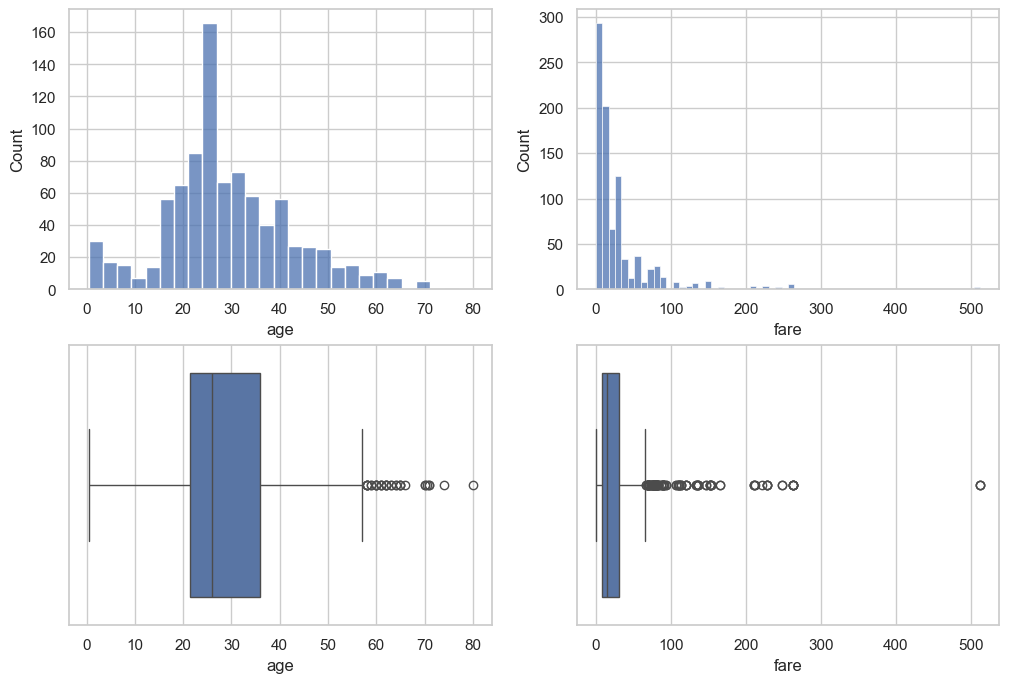

In [81]:
# your code here
print(df[['age', 'fare']].skew().round(2))
# age  ~0.5  -> roughly symmetric, mean is a fine summary
# fare ~4.8  -> heavily right-skewed; use the median, and log-transform it for any distance- or scale-sensitive model.
plt.subplots(2, 2, figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(data=df, x="age")
plt.subplot(2, 2, 2)
sns.histplot(data=df, x="fare")
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x="age")
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x="fare")

### Q3. Show the distribution of `pclass`, `sex` and `embarked` as proportions. Any class that is rare enough to worry about?

<details><summary>hint</summary>

Loop over the columns rather than writing three near-identical blocks.

</details>

<Axes: xlabel='embarked', ylabel='percent'>

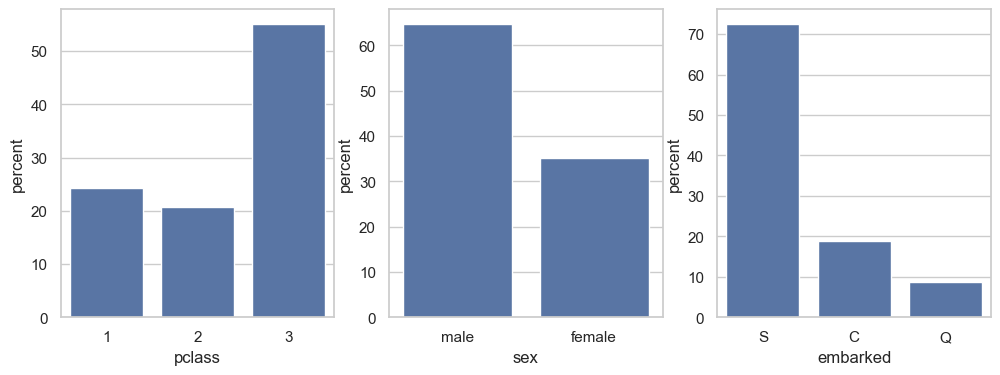

In [82]:
# your code here
# create a countplot for pclass
#sns.countplot(data=df, x="pclass", hue="survived", stat="percent")
plt.subplots(1, 3, figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.countplot(data=df, x="pclass", stat="percent")
plt.subplot(1, 3, 2)
sns.countplot(data=df, x="sex", stat="percent")
plt.subplot(1, 3, 3)
sns.countplot(data=df, x="embarked", stat="percent")

# embarked='Q' is only ~9% -- small, but big enough to keep as its own level.
# at 2% you'd group it into 'Other' with the other rare levels, or merge it into the level it most resembles (by target rate or domain meaning) — that's the 'other' bucketing

---

## Part B — Bivariate: what predicts survival?

### Q4. What is the survival rate by `sex`? By `pclass`? Give counts alongside the rates — a rate on 5 rows is not a finding.

<details><summary>hint</summary>

`.agg(n='count', rate='mean')` names both aggregations in one call.

</details>

<Axes: title={'center': 'Survival Rate by Sex'}, xlabel='sex'>

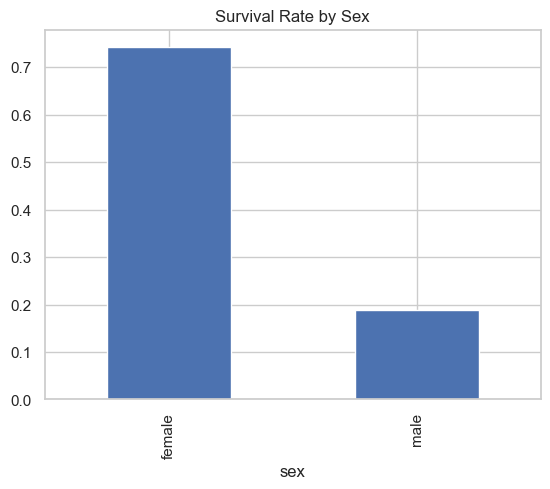

In [83]:
# your code here
df.groupby("sex")["survived"].mean().plot(kind="bar", title="Survival Rate by Sex")

<Axes: xlabel='sex', ylabel='survived'>

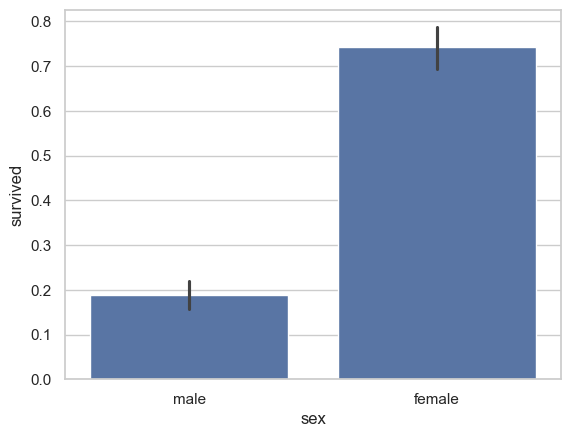

In [84]:
# doing it now with sns
sns.barplot(data=df, x="sex", y="survived")

<Axes: title={'center': 'Survival Rate by Pclass'}, xlabel='pclass'>

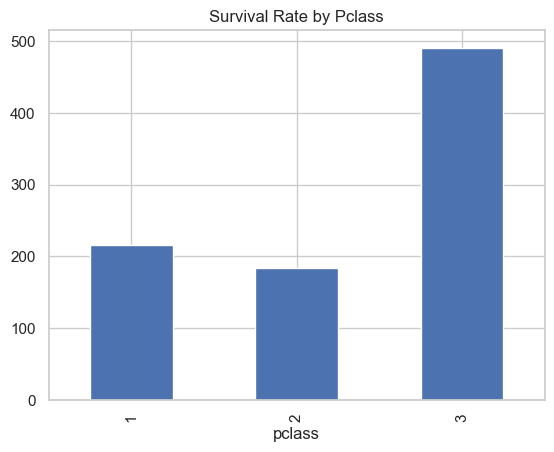

In [85]:
df.groupby("pclass")["survived"].count().plot(kind="bar", title="Survival Rate by Pclass") 
# be careful do not use sum() since it will give you the number of survivors, not the survival rate. Use mean() instead.

In [86]:
for col in ['sex', 'pclass']:
    print(df.groupby(col)['survived'].agg(n='count', rate='mean').round(3), '\n')

          n   rate
sex               
female  314  0.742
male    577  0.189 

          n   rate
pclass            
1       216  0.630
2       184  0.473
3       491  0.242 



### Q5. Now cross `sex` **and** `pclass` together. Present it as a 2×3 table of survival rates. What does 3rd-class male vs 1st-class female tell you?

<details><summary>hint</summary>

`pivot_table` with `aggfunc='mean'` on a 0/1 column gives you a rate table directly. `sns.heatmap(..., annot=True)` makes it readable instantly.

</details>

In [87]:
# your code here
pd.crosstab(df['sex'],df["pclass"]) # this only points to the sum but not the rate

pclass,1,2,3
sex,,,
female,94,76,144
male,122,108,347


In [88]:
pd.pivot_table(df, index='sex', columns='pclass', values='survived', aggfunc=['mean']).round(3) # this gives you both the sum and the rate

mean              
pclass      1      2      3
sex                        
female  0.968  0.921  0.500
male    0.369  0.157  0.135

### Q6. Does `age` differ between survivors and non-survivors? Show it two ways (a boxplot and overlaid distributions), and back it up with a number.

<details><summary>hint</summary>

`hue='survived'` on a histplot overlays the two groups.

</details>

<Axes: xlabel='age'>

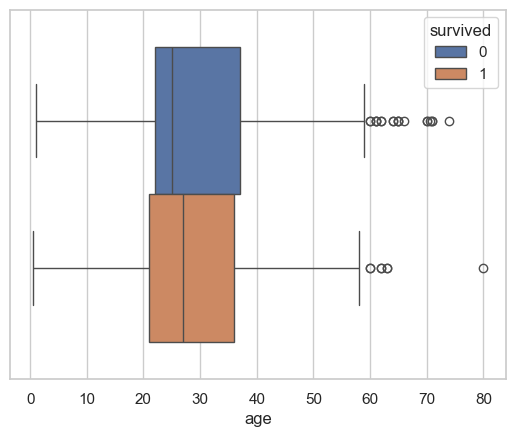

In [89]:
# your code here
sns.boxplot(data=df, x="age", hue="survived")

<Axes: xlabel='survived', ylabel='age'>

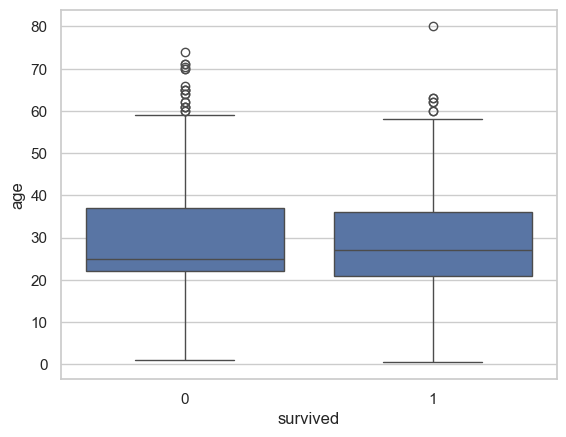

In [90]:
sns.boxplot(data=df, x='survived', y='age')

<Axes: xlabel='age', ylabel='Density'>

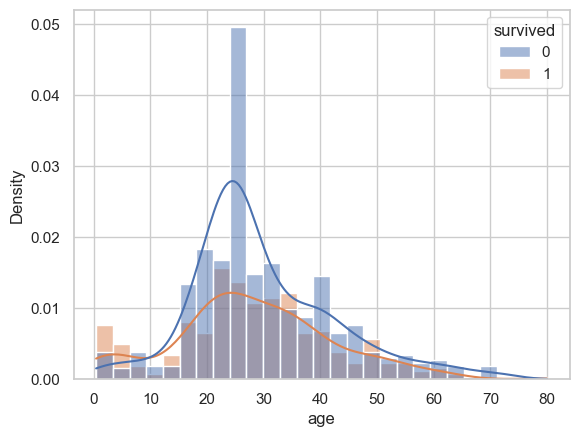

In [91]:
sns.histplot(data=df, x="age", hue="survived", kde=True, stat="density") # kde shows a smoothed version of the histogram, which can help visualize the distribution better.
# use stat="density" to normalize the histogram 

### Q7. Age looked flat overall — but that can hide a non-linear effect. Bin age into
`child / teen / adult / senior` and compute the survival rate per bin.
Did binning reveal something the mean hid?

<details><summary>hint</summary>

`pd.cut` with explicit `bins` and `labels`. Pass `observed=True` to groupby on a categorical to avoid empty-group rows.

</details>

In [92]:
# your code here
df["bin_age"] = pd.cut(df['age'], bins=[0,18,35,60,100], labels=['child','teen','adult','senior'])

In [93]:
df.groupby("bin_age")["survived"].mean()

bin_age
child     0.503597
teen      0.357977
adult     0.384259
senior    0.227273
Name: survived, dtype: float64

### Q8. Cross `embarked` with `pclass` as row-normalised proportions. Does `embarked` actually carry its own signal, or is it a proxy for something else?

<details><summary>hint</summary>

`pd.crosstab(..., normalize='index')` makes each row sum to 1, which is what you want when the row totals differ a lot.

</details>

In [94]:
# your code here
# normalize can be "index", "all", "columns" 
pd.crosstab(df["embarked"], df["pclass"], normalize="index").round(3)*100

# for Q it is true that is mainly class 3, but C and S are more diversified

pclass,1,2,3
embarked,,,
C,50.6,10.1,39.3
Q,2.6,3.9,93.5
S,20.0,25.4,54.6


---

## Part C — Correlation

### Q9. Build a correlation heatmap of the numeric columns. Note any pair above |0.5| —
you'll need this in notebook 03.

<details><summary>hint</summary>

`select_dtypes(include='number')` picks the numeric columns. Drop the ID — its correlation with anything is meaningless.

</details>

<Axes: >

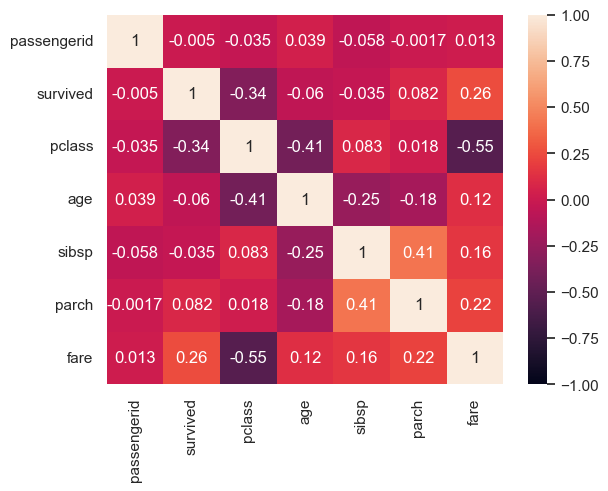

In [95]:
# your code here
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1)

### Q10. `sex` is the single strongest predictor here, but it doesn't appear in your heatmap.
Why not? Fix it, and report the correlation between `sex` and `survived`.

<details><summary>hint</summary>

What does `.corr()` do with an object column? It skips it, without telling you.

</details>

In [96]:
# your code here
df["sex_bool"] = (df.sex == "male").astype(int)

In [97]:
df[["sex_bool", "survived"]].corr()

,sex_bool,survived
sex_bool,1.000000,-0.543351
survived,-0.543351,1.000000


### Q11. `age` has a near-zero correlation with `survived`. Argue why dropping it on that
basis would be a mistake. Support your answer with something you computed earlier.

<details><summary>hint</summary>

Look back at your age-group bar chart. Could a single straight line through that shape capture it?

</details>

In [99]:
# your code here
print(df[['age', 'survived']].corr().round(3))

# Pearson correlation measures only the *linear* part of an association. From Q6 the real
# relationship is a step: children ~58%, then a long flat adult plateau ~37%. A single
# straight line fitted through that is nearly horizontal, so the correlation is ~ -0.06 --
# while `age < 12` remains genuinely predictive, and a tree will find and split on it.
# Never drop a feature on |corr| alone; check a plot or a permutation importance first.
# The general rule: low correlation means "no linear signal", not "no signal".

           age  survived
age       1.00     -0.06
survived -0.06      1.00


---

## Part D — Synthesis

### Q12. Freeform, and this is the one they actually care about. In 3–5 bullets: what are the
strongest drivers of survival, what feature would you engineer next, and what is
the one thing in this data you distrust?

<details><summary>hint</summary>

An interviewer asking this is testing whether you can turn plots into decisions.

</details>

In [ ]:
# your code here